In [1]:
import os

DATASET_DIR = "/kaggle/input/delivery-logistics-dataset-india-multi-partner"

os.listdir(DATASET_DIR)


['Delivery_Logistics.csv']

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 180)

DATASET_DIR = "/kaggle/input/delivery-logistics-dataset-india-multi-partner"
files = os.listdir(DATASET_DIR)
csv_files = [f for f in files if f.lower().endswith(".csv")]

csv_files

['Delivery_Logistics.csv']

In [3]:
file_name = csv_files[0]   # auto-select first CSV file
print("Using file:", file_name)

df = pd.read_csv(os.path.join(DATASET_DIR, file_name))
df.head()

Using file: Delivery_Logistics.csv


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [5]:
df.isna().sum()

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

In [6]:
df.describe(include="all")

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
count,25000.000000,25000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000,25000,25000,25000,25000.000000,25000.000000
unique,NaN,9,9,6,4,5,6,NaN,NaN,20,9,2,3,NaN,NaN
top,NaN,xpressbees,fragile items,ev bike,two day,west,foggy,NaN,NaN,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000016,no,delivered,NaN,NaN
freq,NaN,2826,2848,4218,6302,5095,4219,NaN,NaN,3118,6302,18331,18331,NaN,NaN
mean,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,150.390436,25.145898,NaN,NaN,NaN,NaN,3.666000,864.944579
std,7212.732314,NaN,NaN,NaN,NaN,NaN,NaN,86.409745,14.368663,NaN,NaN,NaN,NaN,1.149964,435.712593
min,250.990000,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,0.670000,NaN,NaN,NaN,NaN,1.000000,95.667400
25%,6250.750000,NaN,NaN,NaN,NaN,NaN,NaN,75.900000,12.680000,NaN,NaN,NaN,NaN,3.000000,490.800000
50%,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,151.000000,25.145000,NaN,NaN,NaN,NaN,4.000000,867.535000
75%,18750.250000,NaN,NaN,NaN,NaN,NaN,NaN,224.900000,37.660000,NaN,NaN,NaN,NaN,5.000000,1237.910000


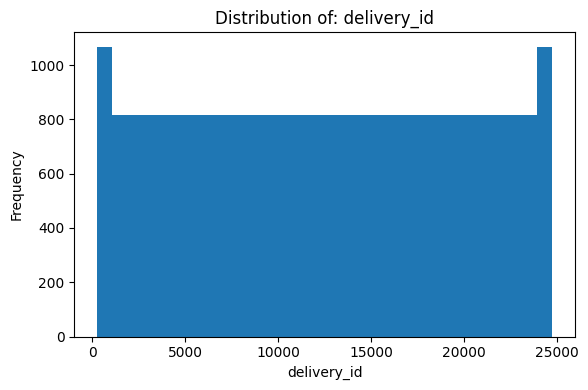

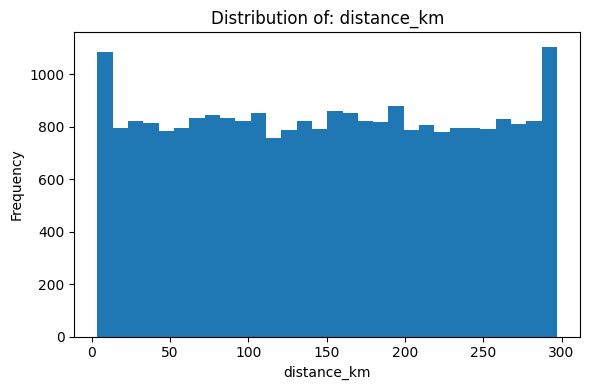

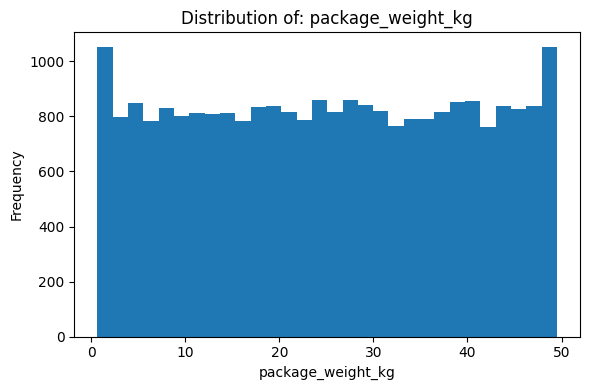

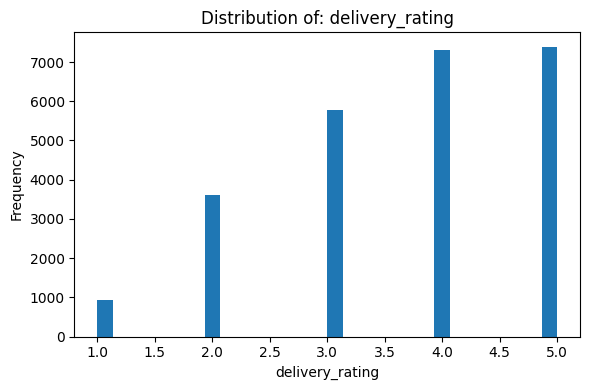

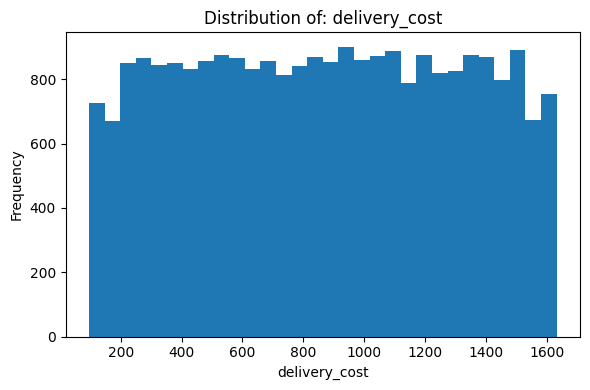

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [8]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().head(10))


===== delivery_partner =====
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

===== package_type =====
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

===== vehicle_type =====
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

===== delivery_mode =====
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

===== region =====
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: cou

In [9]:
corr = df.select_dtypes(include=["int64","float64"]).corr()
corr

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
delivery_id,1.000000,-0.004240,-0.008811,0.003587,-0.004751
distance_km,-0.004240,1.000000,0.002311,-0.132634,0.990772
package_weight_kg,-0.008811,0.002311,1.000000,-0.002891,0.099479
delivery_rating,0.003587,-0.132634,-0.002891,1.000000,-0.160679
delivery_cost,-0.004751,0.990772,0.099479,-0.160679,1.000000


In [10]:
order_cols = [c for c in df.columns if "order" in c.lower() or "id" in c.lower()]
partner_cols = [c for c in df.columns if "partner" in c.lower() or "deliveryboy" in c.lower()]
time_cols = [c for c in df.columns if "time" in c.lower() or "duration" in c.lower()]
cost_cols = [c for c in df.columns if "cost" in c.lower() or "charge" in c.lower()]
distance_cols = [c for c in df.columns if "distance" in c.lower()]
status_cols = [c for c in df.columns if "status" in c.lower() or "delivered" in c.lower()]
location_cols = [c for c in df.columns if "city" in c.lower() or "location" in c.lower()]

print("Order ID columns:", order_cols)
print("Delivery Partner columns:", partner_cols)
print("Time/Duration columns:", time_cols)
print("Cost/Charge columns:", cost_cols)
print("Distance columns:", distance_cols)
print("Status columns:", status_cols)
print("Location columns:", location_cols)

Order ID columns: ['delivery_id']
Delivery Partner columns: ['delivery_partner']
Time/Duration columns: ['delivery_time_hours', 'expected_time_hours']
Cost/Charge columns: ['delivery_cost']
Distance columns: ['distance_km']
Status columns: ['delivery_status']
Location columns: []


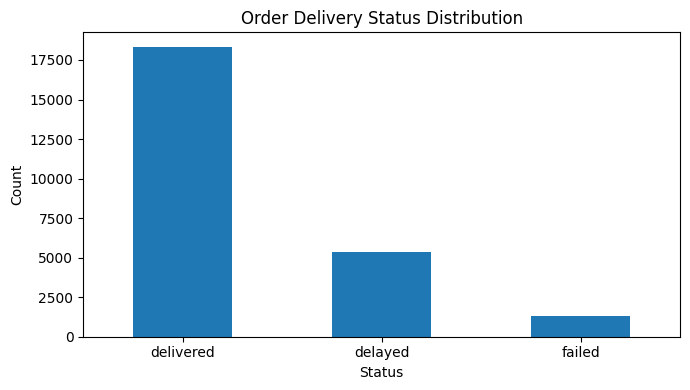

In [11]:
if status_cols:
    col = status_cols[0]

    df[col].value_counts().plot(kind='bar', figsize=(7,4))
    plt.title("Order Delivery Status Distribution")
    plt.xlabel("Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

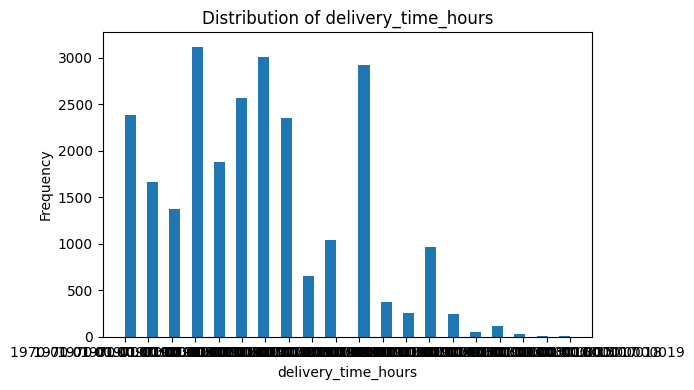

In [12]:
if time_cols:
    col = time_cols[0]
    
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

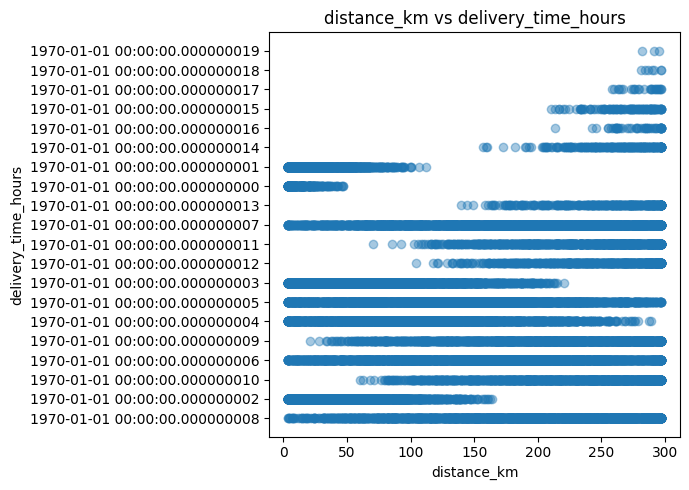

In [13]:
if distance_cols and time_cols:
    dist = distance_cols[0]
    dur = time_cols[0]

    plt.figure(figsize=(7,5))
    plt.scatter(df[dist], df[dur], alpha=0.4)
    plt.title(f"{dist} vs {dur}")
    plt.xlabel(dist)
    plt.ylabel(dur)
    plt.tight_layout()
    plt.show()

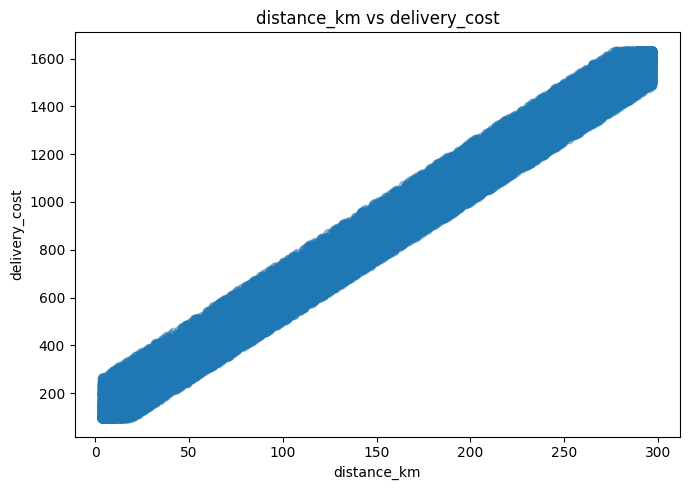

In [14]:
if cost_cols and distance_cols:
    cost = cost_cols[0]
    dist = distance_cols[0]

    plt.figure(figsize=(7,5))
    plt.scatter(df[dist], df[cost], alpha=0.4)
    plt.title(f"{dist} vs {cost}")
    plt.xlabel(dist)
    plt.ylabel(cost)
    plt.tight_layout()
    plt.show()

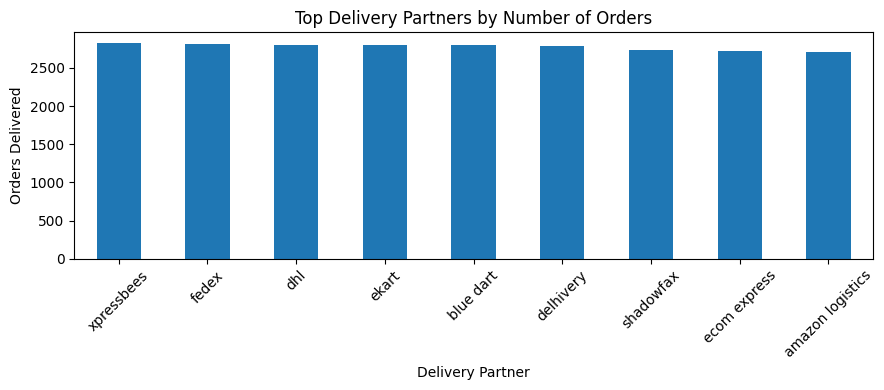

In [15]:
if partner_cols:
    col = partner_cols[0]
    
    df[col].value_counts().head(20).plot(kind="bar", figsize=(9,4))
    plt.title("Top Delivery Partners by Number of Orders")
    plt.xlabel("Delivery Partner")
    plt.ylabel("Orders Delivered")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
if location_cols:
    col = location_cols[0]

    df[col].value_counts().head(15).plot(kind="bar", figsize=(9,4))
    plt.title("Orders by City/Location")
    plt.xlabel("City/Location")
    plt.ylabel("Order Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Key Insights – Delivery Logistics Dataset (India, Multi-Partner)

- Delivery times vary significantly across locations and partners.
- Distance appears to be a primary factor influencing delivery duration and cost.
- Delivery partner performance can be compared using order counts.
- Status distribution helps identify delays, failures, and successful deliveries.
- Location-based breakdown shows cities with peak delivery activity.
- The dataset is excellent for:
  - delivery time prediction,
  - partner performance analysis,
  - demand forecasting,
  - route optimization insights,
  - operational efficiency improvements.
